## Importacion de paquetes y apertura de bases de datos

### Sólo para Drive

In [ ]:
from google.colab import drive

### Necesarios 

In [43]:
# from google.colab import drive

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.base import clone

In [44]:
# RUTAS y BASES
# RUTA FRAN C:\Repositorios\BigDataUBA-Grupo1\TP_SUBE

# DRIVE 

# drive.mount('/content/drive')
# base_25 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2025.csv")
# base_24 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2024.csv")
# base_23 = pd.read_csv("/content/drive/MyDrive/Programacion/dat-ab-usos-2023.csv")

# LOCAL 

base_25 = pd.read_csv("C:/Repositorios/BigDataUBA-Grupo1/TP_SUBE/dat-ab-usos-2025.csv")
base_24 = pd.read_csv("C:/Repositorios/BigDataUBA-Grupo1/TP_SUBE/dat-ab-usos-2024.csv")
base_23 = pd.read_csv("C:/Repositorios/BigDataUBA-Grupo1/TP_SUBE/dat-ab-usos-2023.csv")

print("Base 2023:", base_23.shape)
print("Base 2024:", base_24.shape)
print("Base 2025:", base_25.shape)

Base 2023: (472291, 10)
Base 2024: (504676, 10)
Base 2025: (501048, 10)


## Exploración de base general

Union de las bases 2023 y 2024 que utilizaremos para entrenar y generacion de variables estructurales. Con eso, predecimos 2025.

In [45]:
# Filtramos AMBA
base_23 = base_23[base_23["AMBA"] == "SI"].copy()
base_24 = base_24[base_24["AMBA"] == "SI"].copy()
base_25 = base_25[base_25["AMBA"] == "SI"].copy()

# Unimos
amba = pd.concat([base_23, base_24, base_25], ignore_index=True)
# Asegurar formato fecha
amba["DIA_TRANSPORTE"] = pd.to_datetime(amba["DIA_TRANSPORTE"])

print("AMBA combinado:", amba.shape)
amba.info()

AMBA combinado: (438172, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438172 entries, 0 to 438171
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   DIA_TRANSPORTE   438172 non-null  datetime64[ns]
 1   NOMBRE_EMPRESA   438172 non-null  object        
 2   LINEA            438172 non-null  object        
 3   AMBA             438172 non-null  object        
 4   TIPO_TRANSPORTE  438172 non-null  object        
 5   JURISDICCION     430604 non-null  object        
 6   PROVINCIA        430582 non-null  object        
 7   MUNICIPIO        430582 non-null  object        
 8   CANTIDAD         438172 non-null  int64         
 9   DATO_PRELIMINAR  438172 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 33.4+ MB


In [46]:
# VARIABLES TEMPORALES y filtros
# Aseguramos tipo datetime
amba["DIA_TRANSPORTE"] = pd.to_datetime(amba["DIA_TRANSPORTE"])
# Columna fecha base
amba["fecha"] = amba["DIA_TRANSPORTE"]

# Variables temporales a nivel general (todas las observaciones)
amba["dia_semana"] = amba["fecha"].dt.weekday          # 0 = lunes, 6 = domingo
amba["mes"]        = amba["fecha"].dt.month            # 1–12
amba["anio"]       = amba["fecha"].dt.year
amba["clases"]     = amba["fecha"].dt.month.between(3, 12).astype(int)  # marzo–diciembre = 1

print("Columnas temporales agregadas en amba:", ["fecha", "dia_semana", "mes", "anio", "clases"])

# SUBCONJUNTO: SOLO TREN
df_tren = amba[amba["TIPO_TRANSPORTE"] == "TREN"].copy()

# Ya tenemos 'fecha', 'dia_semana', 'mes', 'anio' desde amba
# Solo agregamos lo que es específico para el modelo de TREN
df_tren = df_tren.sort_values(["LINEA", "fecha"])

# Día del mes y fin de semana (derivados de la fecha / dia_semana)
df_tren["dia_mes"]   = df_tren["fecha"].dt.day
df_tren["fin_semana"] = (df_tren["dia_semana"] >= 5).astype(int)

# Lags por línea
df_tren["lag_1"] = df_tren.groupby("LINEA")["CANTIDAD"].shift(1)
df_tren["lag_7"] = df_tren.groupby("LINEA")["CANTIDAD"].shift(7)

# Medias móviles por línea
df_tren["media_7"] = df_tren.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)
df_tren["media_30"] = df_tren.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
)

# Eliminamos solo filas sin lag_1
df_tren = df_tren.dropna(subset=["lag_1"]).copy()

print("Datos finales TREN (con features):", df_tren.shape)
print("Rango de fechas TREN:", df_tren["fecha"].min().date(), "→", df_tren["fecha"].max().date())


Columnas temporales agregadas en amba: ['fecha', 'dia_semana', 'mes', 'anio', 'clases']
Datos finales TREN (con features): (17312, 21)
Rango de fechas TREN: 2023-01-02 → 2025-12-05


In [47]:
# SOLO SUBTE
df_subte = amba[amba["TIPO_TRANSPORTE"] == "SUBTE"].copy()
df_subte = df_subte.sort_values(["LINEA", "fecha"])

# Día del mes y fin de semana
df_subte["dia_mes"]    = df_subte["fecha"].dt.day # Día del mes
df_subte["fin_semana"] = (df_subte["dia_semana"] >= 5).astype(int) # Fin de semana (0 = laborable, 1 = fin de semana)

# Lags por línea
df_subte["lag_1"] = df_subte.groupby("LINEA")["CANTIDAD"].shift(1) # Lag de 1 día
df_subte["lag_7"] = df_subte.groupby("LINEA")["CANTIDAD"].shift(7) # Lag de 7 días

# Medias móviles por línea

df_subte["media_7"] = df_subte.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
) # Media móvil de 7 días

df_subte["media_30"] = df_subte.groupby("LINEA")["CANTIDAD"].transform(
    lambda x: x.rolling(30, min_periods=1).mean()
) # Media móvil de 30 días

# Eliminamos solo filas sin lag_1
df_subte = df_subte.dropna(subset=["lag_1"]).copy()

print("Datos finales SUBTE (con features):", df_subte.shape)
print("Rango de fechas SUBTE:", df_subte["fecha"].min().date(), "→", df_subte["fecha"].max().date())

Datos finales SUBTE (con features): (7559, 21)
Rango de fechas SUBTE: 2023-01-02 → 2025-12-05


In [48]:
#Elimino datos nulos de ambos datasets
df_tren = df_tren.dropna()
df_subte = df_subte.dropna(subset=["lag_7"])

In [49]:
#Filtro de outliers con IQR
def filtrar_iqr(df, variable):
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_filtrado = df[(df[variable] >= lower) & (df[variable] <= upper)]

    print(f"Filtrado IQR para '{variable}' en:")
    print(f"Valores originales : {len(df)}")
    print(f"Valores filtrados  : {len(df_filtrado)}")
    print(f"Eliminados         : {len(df) - len(df_filtrado)}\n")

    return df_filtrado
df_tren_filtrado  = filtrar_iqr(df_tren,  "CANTIDAD")
df_subte_filtrado = filtrar_iqr(df_subte, "CANTIDAD")

Filtrado IQR para 'CANTIDAD' en:
Valores originales : 17204
Valores filtrados  : 15601
Eliminados         : 1603

Filtrado IQR para 'CANTIDAD' en:
Valores originales : 7505
Valores filtrados  : 7503
Eliminados         : 2



### Analisis exploratorio y descriptivo



Observaciones TREN: 15601

=== Descriptivos de CANTIDAD (TREN) ===


count     15601.000000
mean      26419.390231
std       35615.098964
min        -417.000000
25%         133.000000
50%        3040.000000
75%       52776.000000
max      161914.000000
Name: CANTIDAD, dtype: float64


=== Deciles de CANTIDAD (TREN) ===


0.0      -417.0
0.1        33.0
0.2        93.0
0.3       182.0
0.4       421.0
0.5      3040.0
0.6     15443.0
0.7     43943.0
0.8     60951.0
0.9     83784.0
1.0    161914.0
Name: CANTIDAD, dtype: float64

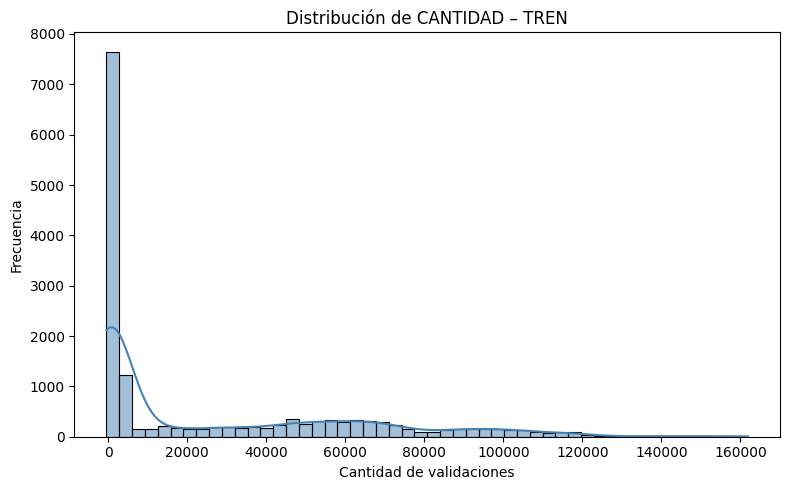

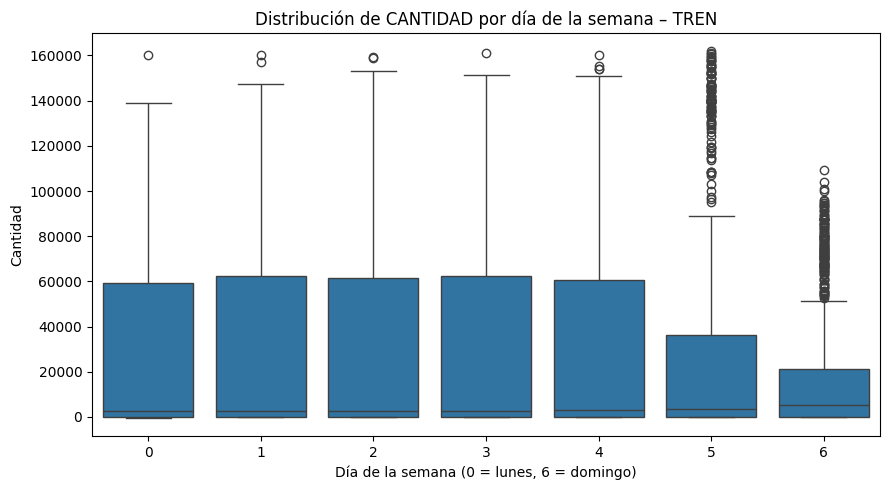

In [50]:
print("Observaciones TREN:", df_tren_filtrado.shape[0])

# --------------------------------------
# DESCRIPTIVOS TREN
# --------------------------------------
print("\n=== Descriptivos de CANTIDAD (TREN) ===")
display(df_tren_filtrado["CANTIDAD"].describe())

print("\n=== Deciles de CANTIDAD (TREN) ===")
display(df_tren_filtrado["CANTIDAD"].quantile([i/10 for i in range(11)]))

# --------------------------------------
# HISTOGRAMA
# --------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_tren_filtrado,
    x="CANTIDAD",
    bins=50,
    kde=True,
    color="steelblue"
)
plt.title("Distribución de CANTIDAD – TREN")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# --------------------------------------
# BOXPLOT POR DÍA DE LA SEMANA
# --------------------------------------
# (asume que ya creaste df_tren["dia_semana"])
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_tren_filtrado,
    x="dia_semana",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por día de la semana – TREN")
plt.xlabel("Día de la semana (0 = lunes, 6 = domingo)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

Observaciones SUBTE: 7503

=== Descriptivos de CANTIDAD (SUBTE) ===


count      7503.000000
mean      76180.002132
std       59624.619283
min           1.000000
25%       26213.500000
50%       69324.000000
75%      112010.500000
max      232812.000000
Name: CANTIDAD, dtype: float64


=== Deciles de CANTIDAD (SUBTE) ===


0.0         1.0
0.1      1438.0
0.2     18302.8
0.3     35031.6
0.4     52454.4
0.5     69324.0
0.6     84139.6
0.7    100884.0
0.8    127374.8
0.9    169587.6
1.0    232812.0
Name: CANTIDAD, dtype: float64

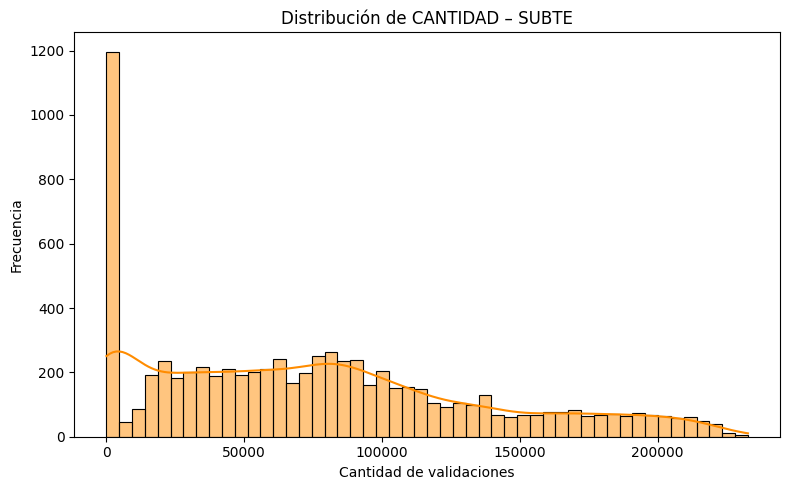

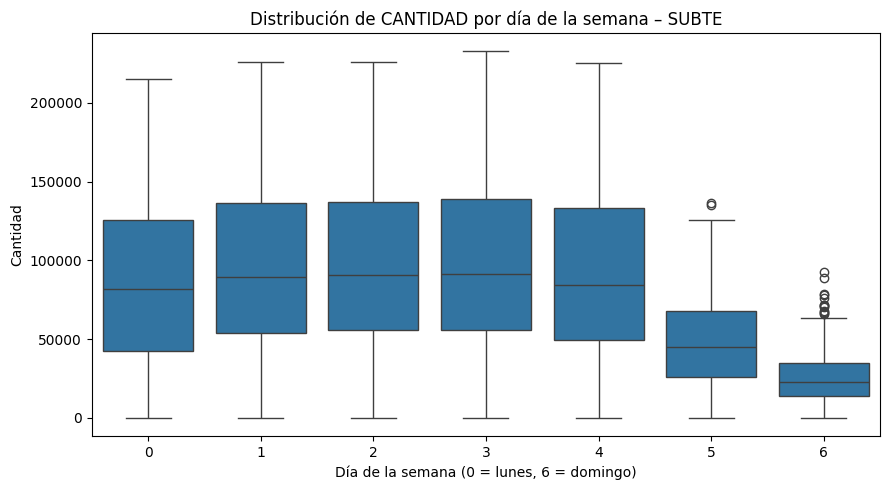

In [51]:
# DESCRIPTIVOS – SUBTE
print("Observaciones SUBTE:", df_subte_filtrado.shape[0])

# --------------------------------------
# DESCRIPTIVOS
# --------------------------------------
print("\n=== Descriptivos de CANTIDAD (SUBTE) ===")
display(df_subte_filtrado["CANTIDAD"].describe())

print("\n=== Deciles de CANTIDAD (SUBTE) ===")
display(df_subte_filtrado["CANTIDAD"].quantile([i/10 for i in range(11)]))

# --------------------------------------
# HISTOGRAMA
# --------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(
    data=df_subte_filtrado,
    x="CANTIDAD",
    bins=50,
    kde=True,
    color="darkorange"
)
plt.title("Distribución de CANTIDAD – SUBTE")
plt.xlabel("Cantidad de validaciones")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# --------------------------------------
# BOXPLOT POR DÍA DE LA SEMANA
# --------------------------------------
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df_subte_filtrado,
    x="dia_semana",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por día de la semana – SUBTE")
plt.xlabel("Día de la semana (0 = lunes, 6 = domingo)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

#### Por línea

In [52]:
# DESCRIPTIVOS DE USO POR LÍNEA (TREN)
desc_por_linea = (
    df_tren_filtrado
    .groupby("LINEA")["CANTIDAD"]
    .agg(
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .sort_values("media", ascending=False)
)

display(desc_por_linea.round(0))

,media,mediana,desvio,minimo,maximo,p25,p75
LINEA,,,,,,,
FFCC_SANM,81388.0,93789.0,34318.0,22,128672,61972.0,107698.0
FFCC ROCA,78189.0,75934.0,30907.0,7,160886,65176.0,89396.0
FFCC_BELGRANO_NORTE,76314.0,87711.0,28377.0,1,126209,54154.0,97606.0
FFCC SAR,73092.0,42983.0,52027.0,5,161914,30141.0,133244.0
FCC MITRE_TIGRE,55331.0,56402.0,23049.0,-1,123243,39986.0,71547.0
FFCC URQUIZA,50228.0,60576.0,21811.0,14,84251,30340.0,67904.0
FFCC_SUAREZ,43483.0,53052.0,22137.0,0,77905,20108.0,61584.0
FFCC_BELG_SUR,38918.0,44456.0,15989.0,-11,73310,34746.0,48734.0
FFCC_TREN_COSTA,3668.0,3574.0,1038.0,38,7003,3035.0,4277.0


In [53]:
# DESCRIPTIVOS DE USO POR LÍNEA (SUBTE)
desc_por_linea_subte = (
    df_subte_filtrado
    .groupby("LINEA")["CANTIDAD"]
    .agg(
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max",
        p25=lambda x: x.quantile(0.25),
        p75=lambda x: x.quantile(0.75)
    )
    .sort_values("media", ascending=False)
)

display(desc_por_linea_subte.round(0))

,media,mediana,desvio,minimo,maximo,p25,p75
LINEA,,,,,,,
LINEA_B,131261.0,128167.0,59481.0,1,232812,81995.0,181009.0
LINEA SUBTE D,109637.0,102963.0,60010.0,1,232747,59129.0,155122.0
LINEA_A,109484.0,105380.0,54918.0,6,222073,65568.0,157987.0
LINEA SUBTE C,82839.0,86937.0,35858.0,1,188687,50475.0,110873.0
LINEA SUBTE H,57007.0,61298.0,26156.0,4,110570,34483.0,78537.0
LINEA SUBTE E,49937.0,51545.0,25561.0,6,120366,25207.0,73502.0
LIN_VERDE_D,4323.0,5623.0,2018.0,683,6167,2384.0,5921.0
LIN_PREMETRO,1344.0,1318.0,655.0,1,4704,940.0,1665.0
LIN_AMARILLA_C,397.0,454.0,134.0,104,558,320.0,488.0


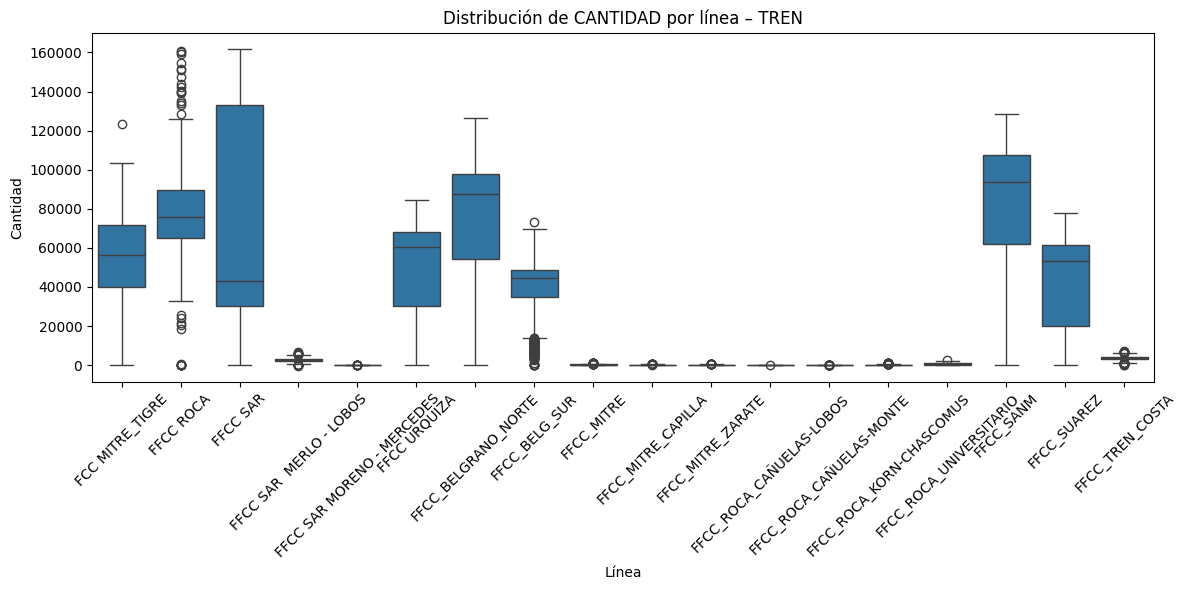

In [54]:
#Boxplot por linea - Tren

plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_tren_filtrado,
    x="LINEA",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por línea – TREN")
plt.xlabel("Línea")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

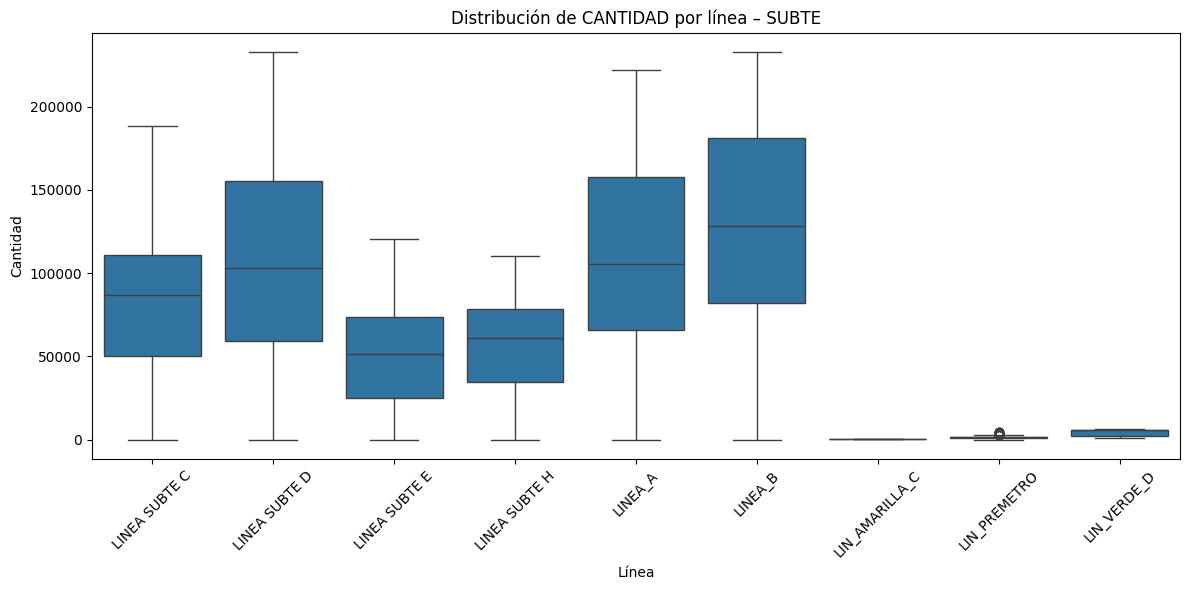

In [55]:
# BOXPLOT POR LÍNEA – SUBTE
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_subte_filtrado,
    x="LINEA",
    y="CANTIDAD"
)
plt.title("Distribución de CANTIDAD por línea – SUBTE")
plt.xlabel("Línea")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Por día de semana

In [56]:
# DESCRIPTIVOS POR DÍA DE LA SEMANA – TREN vs SUBTE
def descriptivos_por_dia(df, nombre):
    stats = (
        df
        .groupby("dia_semana")["CANTIDAD"]
        .agg(
            media="mean",
            mediana="median",
            desvio="std",
            observaciones="count"
        )
    )

    stats.index = [
        "Lunes", "Martes", "Miércoles",
        "Jueves", "Viernes", "Sábado", "Domingo"
    ]

    print(f"\n=== {nombre} ===")
    display(stats.round(0))
    return stats

# TREN
stats_tren = descriptivos_por_dia(df_tren_filtrado, "Uso por día de la semana – TREN")

# SUBTE
stats_subte = descriptivos_por_dia(df_subte_filtrado, "Uso por día de la semana – SUBTE")


=== Uso por día de la semana – TREN ===


,media,mediana,desvio,observaciones
Lunes,28563.0,2743.0,36592.0,2204
Martes,30382.0,2716.0,38438.0,2201
Miércoles,29867.0,2651.0,38084.0,2196
Jueves,30262.0,2770.0,38255.0,2185
Viernes,30222.0,3045.0,38266.0,2197
Sábado,22912.0,3447.0,33477.0,2272
Domingo,13719.0,5166.0,19651.0,2346



=== Uso por día de la semana – SUBTE ===


,media,mediana,desvio,observaciones
Lunes,85664.0,81958.0,58433.0,1076
Martes,94444.0,89710.0,62079.0,1074
Miércoles,94715.0,90592.0,62276.0,1072
Jueves,96060.0,91256.0,62774.0,1068
Viernes,90372.0,84555.0,60473.0,1077
Sábado,47252.0,44854.0,31462.0,1068
Domingo,24389.0,22614.0,16617.0,1068


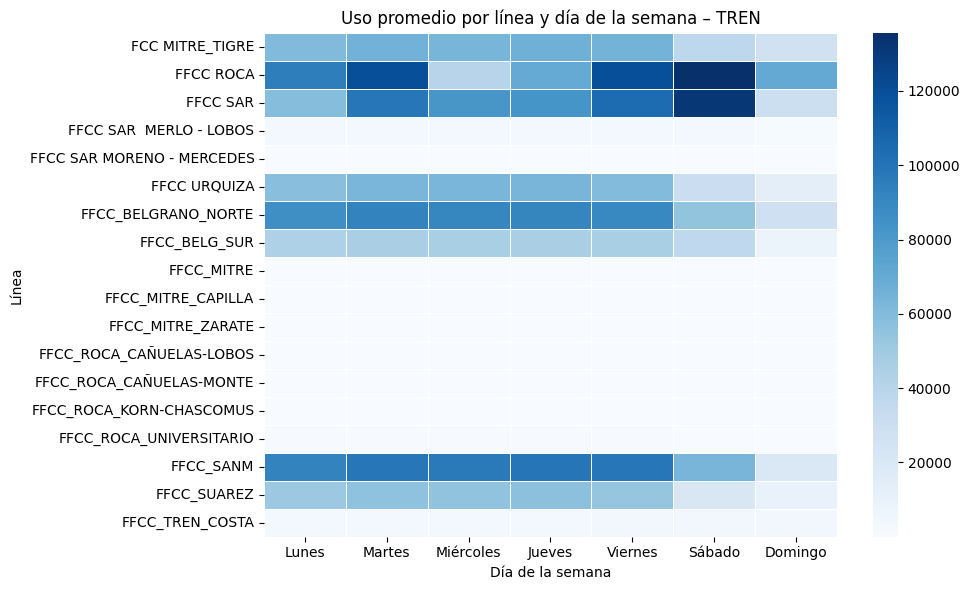

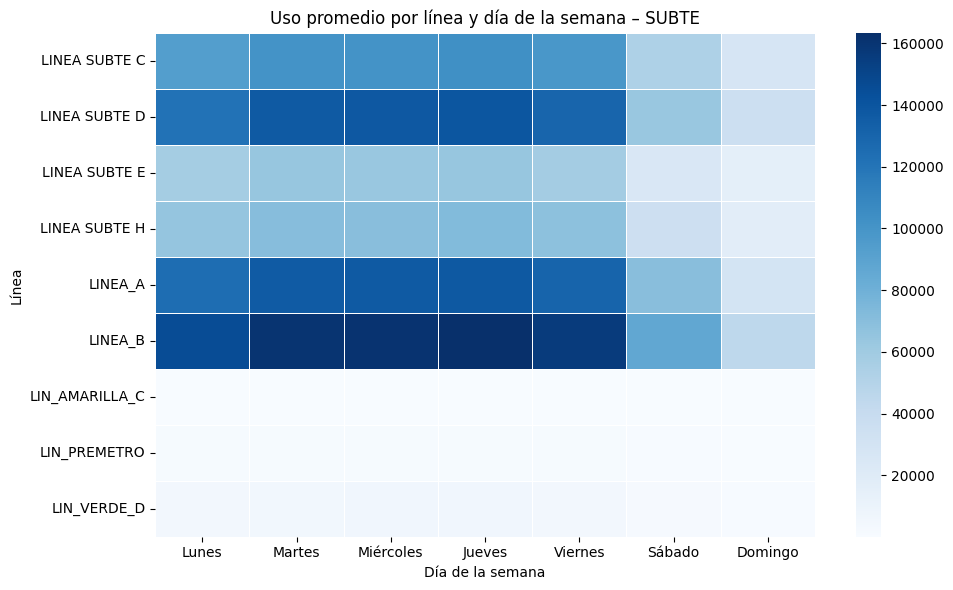

In [57]:
# HEATMAP: USO PROMEDIO POR LÍNEA Y DÍA – TREN vs SUBTE
def heatmap_linea_dia(df, nombre):
    heat_data = (
        df
        .groupby(["LINEA", "dia_semana"])["CANTIDAD"]
        .mean()
        .unstack()
    )

    heat_data.columns = [
        "Lunes", "Martes", "Miércoles",
        "Jueves", "Viernes", "Sábado", "Domingo"
    ]

    plt.figure(figsize=(10,6))
    sns.heatmap(
        heat_data,
        cmap="Blues",
        linewidths=0.5
    )
    plt.title(f"Uso promedio por línea y día de la semana – {nombre}")
    plt.xlabel("Día de la semana")
    plt.ylabel("Línea")
    plt.tight_layout()
    plt.show()

# TREN
heatmap_linea_dia(df_tren_filtrado, "TREN")

# SUBTE
heatmap_linea_dia(df_subte_filtrado, "SUBTE")


LINEA,FCC MITRE_TIGRE,FFCC ROCA,FFCC SAR,FFCC SAR MERLO - LOBOS,FFCC SAR MORENO - MERCEDES,FFCC URQUIZA,FFCC_BELGRANO_NORTE,FFCC_BELG_SUR,FFCC_MITRE,FFCC_MITRE_CAPILLA,FFCC_MITRE_ZARATE,FFCC_ROCA_CAÑUELAS-LOBOS,FFCC_ROCA_CAÑUELAS-MONTE,FFCC_ROCA_KORN-CHASCOMUS,FFCC_ROCA_UNIVERSITARIO,FFCC_SANM,FFCC_SUAREZ,FFCC_TREN_COSTA
anio,,,,,,,,,,,,,,,,,,
2023,63124.0,71160.0,75207.0,2876.0,23.0,53363.0,83473.0,43825.0,489.0,NaN,258.0,46.0,47.0,321.0,1004.0,82427.0,43932.0,3522.0
2024,60205.0,84806.0,67104.0,2414.0,16.0,48780.0,73355.0,36862.0,180.0,169.0,206.0,46.0,30.0,221.0,628.0,76215.0,46941.0,3465.0
2025,40671.0,78313.0,76445.0,NaN,NaN,48482.0,71949.0,35956.0,160.0,123.0,114.0,34.0,16.0,173.0,562.0,85876.0,39274.0,4041.0


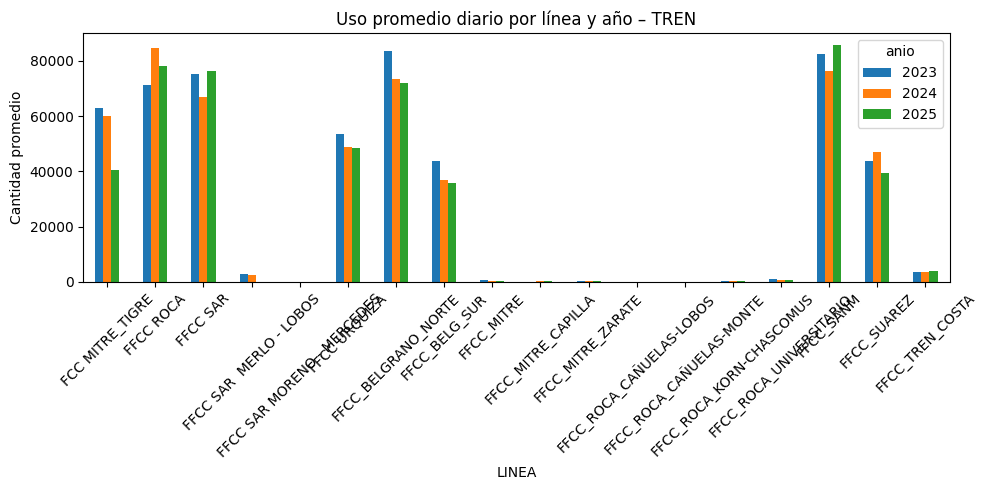

In [58]:
# Interanual 2023-2024-2025
# USO PROMEDIO POR AÑO Y LÍNEA

uso_anual = (
    df_tren_filtrado
    .groupby(["anio", "LINEA"])["CANTIDAD"]
    .mean()
    .unstack()
)

display(uso_anual.round(0))

uso_anual.T.plot(kind="bar", figsize=(10,5))
plt.title("Uso promedio diario por línea y año – TREN")
plt.ylabel("Cantidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

LINEA,LINEA SUBTE C,LINEA SUBTE D,LINEA SUBTE E,LINEA SUBTE H,LINEA_A,LINEA_B,LIN_AMARILLA_C,LIN_PREMETRO,LIN_VERDE_D
anio,,,,,,,,,
2023,96117.0,146612.0,57381.0,64594.0,133206.0,160147.0,NaN,1401.0,NaN
2024,85635.0,102949.0,54915.0,60960.0,117612.0,137122.0,NaN,1040.0,NaN
2025,65845.0,77158.0,36717.0,44740.0,75682.0,94531.0,397.0,1609.0,4323.0


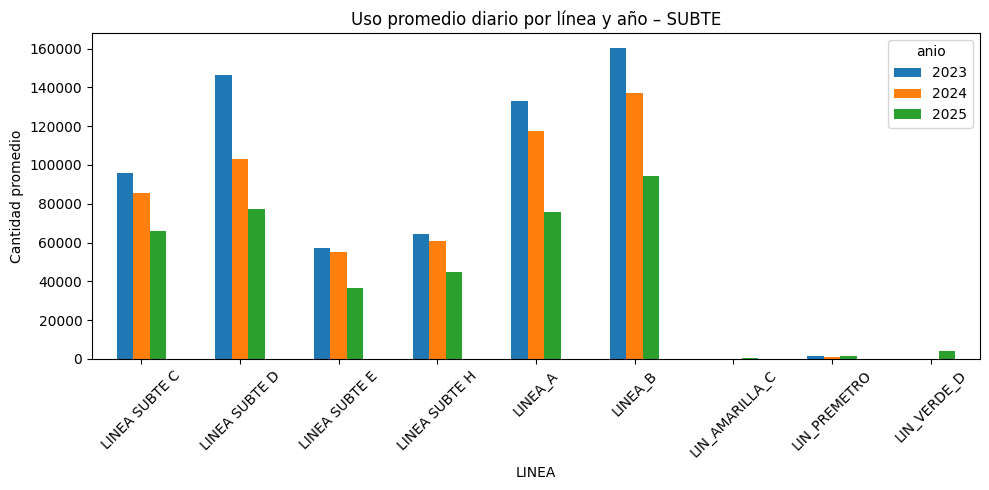

In [59]:
# INTERANUAL 2023–2024–2025
# USO PROMEDIO POR AÑO Y LÍNEA – SUBTE
uso_anual_subte = (
    df_subte_filtrado
    .groupby(["anio", "LINEA"])["CANTIDAD"]
    .mean()
    .unstack()
)

display(uso_anual_subte.round(0))

uso_anual_subte.T.plot(kind="bar", figsize=(10,5))
plt.title("Uso promedio diario por línea y año – SUBTE")
plt.ylabel("Cantidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## MODELIZACIÓN

### SPLIT: ENTRENAMIENTO VS VALIDACIÓN

In [60]:
# TRAIN / TEST SPLIT – TREN y SUBTE

corte = pd.to_datetime("2024-12-31")

def hacer_split_train_test(df, nombre, corte):
    print(f"\n=== Split para {nombre} ===")
    # Split por fecha
    train = df[df["fecha"] < corte].copy()
    test  = df[df["fecha"] >= corte].copy()

    print("Split inicial por fecha:")
    print("Train:", train.shape)
    print("Test :", test.shape)
    return train, test

train_tren, test_tren   = hacer_split_train_test(df_tren_filtrado,  "TREN",  corte)
train_subte, test_subte = hacer_split_train_test(df_subte_filtrado, "SUBTE", corte)


=== Split para TREN ===
Split inicial por fecha:
Train: (11038, 21)
Test : (4563, 21)

=== Split para SUBTE ===
Split inicial por fecha:
Train: (5013, 21)
Test : (2490, 21)


In [61]:
# VARIABLES EXPLICATIVAS – TREN y SUBTE
# Variables numéricas y categóricas (comunes a ambos)
numeric_features = [
    "lag_1", "lag_7", "media_7", "media_30",
    "anio", "mes", "dia_mes", "dia_semana", "fin_semana"
]

categorical_features = ["LINEA"]


def preparar_X_y(train, test, nombre):
    """
    Prepara X_train, y_train, X_test, y_test
    para un medio de transporte.
    """
    X_train = train[numeric_features + categorical_features].copy()
    y_train = train["CANTIDAD"].copy()

    X_test  = test[numeric_features + categorical_features].copy()
    y_test  = test["CANTIDAD"].copy()

    print(f"\nVariables listas para {nombre}:")
    print("X_train:", X_train.shape, "| y_train:", y_train.shape)
    print("X_test :", X_test.shape,  "| y_test :", y_test.shape)

    return X_train, y_train, X_test, y_test


# TREN
X_train_tren, y_train_tren, X_test_tren, y_test_tren = preparar_X_y(
    train_tren, test_tren, "TREN"
)

# SUBTE
X_train_subte, y_train_subte, X_test_subte, y_test_subte = preparar_X_y(
    train_subte, test_subte, "SUBTE"
)


Variables listas para TREN:
X_train: (11038, 10) | y_train: (11038,)
X_test : (4563, 10) | y_test : (4563,)

Variables listas para SUBTE:
X_train: (5013, 10) | y_train: (5013,)
X_test : (2490, 10) | y_test : (2490,)


### LASSO Y BAGGING

In [62]:
def entrenar_modelo_con_lasso_y_bagging(X_train, y_train, X_test, y_test, nombre_modelo):

    print(f"\n==============================")
    print(f" ENTRENANDO MODELO: {nombre_modelo}")
    print(f"==============================")

    # 1. Preprocesamiento para LASSO (OHE + Escalado)
    preprocess_lasso = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ])

    # 2. Pipeline LASSO
    pipe_lasso = Pipeline([
        ("prep", preprocess_lasso),
        ("model", Lasso(max_iter=10000, random_state=42))
    ])

    # 3. Búsqueda de alpha con GridSearchCV (logspace)
    param_grid = {"model__alpha": np.logspace(-4, 2, 20)}
    grid = GridSearchCV(
        pipe_lasso,
        param_grid=param_grid,
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    best_lasso = grid.best_estimator_
    best_alpha = grid.best_params_["model__alpha"]
    print(f"\n🔎 Mejor alpha para LASSO ({nombre_modelo}): {best_alpha:.6f}")

    # 4. Métricas del modelo LASSO (en TEST)
    y_pred_lasso = best_lasso.predict(X_test)
    mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
    rmse_lasso = np.sqrt(mse_lasso)
    mae_lasso  = mean_absolute_error(y_test, y_pred_lasso)
    r2_lasso   = r2_score(y_test, y_pred_lasso)

    print(f"\n📊 MÉTRICAS DEL MODELO LASSO ({nombre_modelo})")
    print(f"   ▶ MAE  : {mae_lasso:.4f}")
    print(f"   ▶ RMSE : {rmse_lasso:.4f}")
    print(f"   ▶ R²   : {r2_lasso:.4f}")

    # 5. Identificar variables seleccionadas por LASSO
    #    (coeficientes distintos de cero)
    lasso_step = best_lasso.named_steps["model"]
    coef = lasso_step.coef_

    # Columnas del OneHot + numéricas
    ohe = best_lasso.named_steps["prep"].named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(categorical_features)

    num_feature_names = numeric_features
    all_features = np.concatenate([num_feature_names, cat_feature_names])

    selected_mask = (coef != 0)
    selected_features = all_features[selected_mask]

    print(f"\n✅ Variables seleccionadas por LASSO para {nombre_modelo}:")
    print(selected_features)

    # 6. Construir X_train_sel y X_test_sel usando SOLO esas columnas
    #    Primero, transformar X_train y X_test con el mismo preprocess de LASSO
    X_train_trans = best_lasso.named_steps["prep"].transform(X_train)
    X_test_trans  = best_lasso.named_steps["prep"].transform(X_test)

    # Pasar a DataFrame para filtrar por nombre de columnas
    df_train_trans = pd.DataFrame(X_train_trans, columns=all_features)
    df_test_trans  = pd.DataFrame(X_test_trans,  columns=all_features)

    X_train_sel = df_train_trans[selected_features]
    X_test_sel  = df_test_trans[selected_features]

    # 7. Bagging sobre las variables seleccionadas
    base_tree = DecisionTreeRegressor(
        max_depth=None,
        random_state=42
    )

    bagging = BaggingRegressor(
        estimator=base_tree,
        n_estimators=200,
        max_samples=0.8,
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )

    bagging.fit(X_train_sel, y_train)
    y_pred_bag = bagging.predict(X_test_sel)

    mse_bag  = mean_squared_error(y_test, y_pred_bag)
    rmse_bag = np.sqrt(mse_bag)
    mae_bag  = mean_absolute_error(y_test, y_pred_bag)
    r2_bag   = r2_score(y_test, y_pred_bag)

    print(f"\n📊 MÉTRICAS BAGGING CON LASSO PREVIO PARA {nombre_modelo}")
    print(f"   ▶ MAE  : {mae_bag:.4f}")
    print(f"   ▶ RMSE : {rmse_bag:.4f}")
    print(f"   ▶ R²   : {r2_bag:.4f}\n")

    return {
        "alpha": best_alpha,
        "variables": selected_features,
        "bagging_model": bagging,
        "preprocess_lasso": best_lasso.named_steps["prep"],
        "X_train_sel": X_train_sel,
        "X_test_sel": X_test_sel,
        # Métricas y predicciones LASSO
        "mae_lasso": mae_lasso,
        "rmse_lasso": rmse_lasso,
        "r2_lasso": r2_lasso,
        "y_pred_lasso": y_pred_lasso,
        # Métricas y predicciones Bagging+LASSO
        "mae_bag_lasso": mae_bag,
        "rmse_bag_lasso": rmse_bag,
        "r2_bag_lasso": r2_bag,
        "y_pred_bag_lasso": y_pred_bag,
        # Para referencia
        "y_test": y_test
    }

#### ENTRENAMIENTO Y MÉTRICAS

In [63]:
# ==== ENTRENAR PARA TREN ====
res_tren = entrenar_modelo_con_lasso_y_bagging(
    X_train_tren, y_train_tren,
    X_test_tren, y_test_tren,
    nombre_modelo="TREN"
)

# ==== ENTRENAR PARA SUBTE ====
res_subte = entrenar_modelo_con_lasso_y_bagging(
    X_train_subte, y_train_subte,
    X_test_subte, y_test_subte,
    nombre_modelo="SUBTE"
)



 ENTRENANDO MODELO: TREN

🔎 Mejor alpha para LASSO (TREN): 5.455595

📊 MÉTRICAS DEL MODELO LASSO (TREN)
   ▶ MAE  : 8325.6318
   ▶ RMSE : 14014.1319
   ▶ R²   : 0.8433

✅ Variables seleccionadas por LASSO para TREN:
['lag_1' 'lag_7' 'media_7' 'media_30' 'anio' 'mes' 'dia_mes' 'dia_semana'
 'fin_semana' 'LINEA_FCC MITRE_TIGRE' 'LINEA_FFCC ROCA' 'LINEA_FFCC SAR'
 'LINEA_FFCC SAR  MERLO - LOBOS' 'LINEA_FFCC SAR MORENO - MERCEDES'
 'LINEA_FFCC URQUIZA' 'LINEA_FFCC_BELGRANO_NORTE' 'LINEA_FFCC_BELG_SUR'
 'LINEA_FFCC_MITRE' 'LINEA_FFCC_MITRE_ZARATE'
 'LINEA_FFCC_ROCA_CAÑUELAS-LOBOS' 'LINEA_FFCC_ROCA_CAÑUELAS-MONTE'
 'LINEA_FFCC_ROCA_KORN-CHASCOMUS' 'LINEA_FFCC_ROCA_UNIVERSITARIO'
 'LINEA_FFCC_SANM' 'LINEA_FFCC_SUAREZ' 'LINEA_FFCC_TREN_COSTA']

📊 MÉTRICAS BAGGING CON LASSO PREVIO PARA TREN
   ▶ MAE  : 3991.2173
   ▶ RMSE : 9527.6807
   ▶ R²   : 0.9276


 ENTRENANDO MODELO: SUBTE

🔎 Mejor alpha para LASSO (SUBTE): 23.357215

📊 MÉTRICAS DEL MODELO LASSO (SUBTE)
   ▶ MAE  : 11009.9167
   ▶ RMSE 

### BAGGING + OHE

In [64]:
# PIPELINE: ONE-HOT + BAGGING REGRESSOR (sin regularizacion) PARA TREN Y SUBTE

# Árbol base (se reutiliza la misma especificación)
base_tree = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

# ------------------ TREN ------------------
bagging_tren = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

preprocess_tren = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_tren = Pipeline(steps=[
    ("prep", preprocess_tren),
    ("model", bagging_tren)
])

# ------------------ SUBTE ------------------
bagging_subte = BaggingRegressor(
    estimator=base_tree,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

preprocess_subte = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

pipe_subte = Pipeline(steps=[
    ("prep", preprocess_subte),
    ("model", bagging_subte)
])


In [65]:
# ENTRENAR MODELO PARA TREN Y SUBTE
mae_tren = rmse_tren = r2_tren = None
mae_subte = rmse_subte = r2_subte = None

for tipo, X_tr, y_tr, X_te, y_te in [
    ("TREN",  X_train_tren,  y_train_tren,  X_test_tren,  y_test_tren),
    ("SUBTE", X_train_subte, y_train_subte, X_test_subte, y_test_subte)
]:
    print(f"\nEntrenando modelo Bagging ({tipo})...")

    # Seleccionar el pipeline correcto basado en el tipo
    if tipo == "TREN":
        current_pipe = pipe_tren
    elif tipo == "SUBTE":
        current_pipe = pipe_subte
    else:
        raise ValueError("Tipo de transporte desconocido")

    current_pipe.fit(X_tr, y_tr)

    # Predicción en test
    y_pred = current_pipe.predict(X_te)

    # MÉTRICAS
    mae = mean_absolute_error(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_te, y_pred)

    print(f"\n===== RESULTADOS BAGGING ({tipo}) =====")
    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"R²  : {r2:,.3f}")

    # Guardar resultados específicos para TREN y SUBTE
    if tipo == "TREN":
        mae_tren = mae
        rmse_tren = rmse
        r2_tren = r2
        y_pred_tren = y_pred # Also save y_pred for plotting
    elif tipo == "SUBTE":
        mae_subte = mae
        rmse_subte = rmse
        r2_subte = r2
        y_pred_subte = y_pred # Also save y_pred for plotting



Entrenando modelo Bagging (TREN)...

===== RESULTADOS BAGGING (TREN) =====
MAE : 3,990.23
RMSE: 9,556.84
R²  : 0.927

Entrenando modelo Bagging (SUBTE)...

===== RESULTADOS BAGGING (SUBTE) =====
MAE : 8,120.66
RMSE: 13,559.19
R²  : 0.882


### OLS VS BAGGINS

In [66]:
# COMPARACION OLS VS BAGGING
# Inicializo variables para guardar resultados de OLS
mae_ols_tren = rmse_ols_tren = r2_ols_tren = None
mae_ols_subte = rmse_ols_subte = r2_ols_subte = None
y_pred_ols_tren = y_pred_ols_subte = None

for tipo, X_train, X_test, y_train, y_test in [
    ("TREN",  X_train_tren,  X_test_tren,  y_train_tren,  y_test_tren),
    ("SUBTE", X_train_subte, X_test_subte, y_train_subte, y_test_subte)
]:

    print(f"\n================ OLS {tipo} ================")

    # OneHot para OLS
    X_train_dum = pd.get_dummies(
        X_train,
        columns=categorical_features,
        drop_first=True
    )

    X_test_dum = pd.get_dummies(
        X_test,
        columns=categorical_features,
        drop_first=True
    )

    # y como float
    y_train_ols = y_train.astype(float)
    y_test_ols  = y_test.astype(float)

    # Limpiar NaN SOLO en train
    df_train = pd.concat(
        [y_train_ols.rename("CANTIDAD"), X_train_dum],
        axis=1
    ).dropna()

    y_train_ols = df_train["CANTIDAD"]
    X_train_ols = df_train.drop(columns="CANTIDAD")

    # Alinear test con train
    X_test_ols = X_test_dum.reindex(
        columns=X_train_ols.columns,
        fill_value=0
    )

    # A float
    X_train_ols = X_train_ols.astype(float)
    X_test_ols  = X_test_ols.astype(float)

    # Constante
    X_train_ols = sm.add_constant(X_train_ols)
    X_test_ols  = sm.add_constant(X_test_ols)

    # Ajustar modelo
    ols_model = sm.OLS(y_train_ols, X_train_ols).fit()
    print(ols_model.summary())

    # Predicción
    y_pred_ols = ols_model.predict(X_test_ols)

    # Quitar NaN en test para métricas
    mask = (~y_test_ols.isna()) & (~pd.isna(y_pred_ols))
    y_test_valid = y_test_ols[mask]
    y_pred_valid = y_pred_ols[mask]

    # Métricas OLS
    mae_ols  = mean_absolute_error(y_test_valid, y_pred_valid)
    rmse_ols = np.sqrt(mean_squared_error(y_test_valid, y_pred_valid))
    r2_ols   = r2_score(y_test_valid, y_pred_valid)

    print(f"\nMÉTRICAS OLS ({tipo})")
    print(f"MAE : {mae_ols:,.2f}")
    print(f"RMSE: {rmse_ols:,.2f}")
    print(f"R²  : {r2_ols:,.3f}")

    # Guardar resultados de OLS por tipo
    if tipo == "TREN":
        mae_ols_tren = mae_ols
        rmse_ols_tren = rmse_ols
        r2_ols_tren = r2_ols
        y_pred_ols_tren = y_pred_ols
    else:  # SUBTE
        mae_ols_subte = mae_ols
        rmse_ols_subte = rmse_ols
        r2_ols_subte = r2_ols
        y_pred_ols_subte = y_pred_ols


================ OLS TREN ================
                            OLS Regression Results                            
Dep. Variable:               CANTIDAD   R-squared:                       0.863
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     2658.
Date:                mié, 10 dic 2025   Prob (F-statistic):               0.00
Time:                        15:52:36   Log-Likelihood:            -1.2042e+05
No. Observations:               11038   AIC:                         2.409e+05
Df Residuals:                   11011   BIC:                         2.411e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [67]:
# ============================
# TABLA COMPARATIVA – TODOS LOS MODELOS
# ============================

filas = []

# ----- TREN -----
filas.append({
    "Tipo": "TREN",
    "Modelo": "OLS",
    "MAE": mae_ols_tren,
    "RMSE": rmse_ols_tren,
    "R2": r2_ols_tren
})
filas.append({
    "Tipo": "TREN",
    "Modelo": "Bagging (pipeline)",
    "MAE": mae_tren,
    "RMSE": rmse_tren,
    "R2": r2_tren
})
filas.append({
    "Tipo": "TREN",
    "Modelo": "LASSO",
    "MAE": res_tren["mae_lasso"],
    "RMSE": res_tren["rmse_lasso"],
    "R2": res_tren["r2_lasso"]
})
filas.append({
    "Tipo": "TREN",
    "Modelo": "Bagging + LASSO",
    "MAE": res_tren["mae_bag_lasso"],
    "RMSE": res_tren["rmse_bag_lasso"],
    "R2": res_tren["r2_bag_lasso"]
})

# ----- SUBTE -----
filas.append({
    "Tipo": "SUBTE",
    "Modelo": "OLS",
    "MAE": mae_ols_subte,
    "RMSE": rmse_ols_subte,
    "R2": r2_ols_subte
})
filas.append({
    "Tipo": "SUBTE",
    "Modelo": "Bagging (pipeline)",
    "MAE": mae_subte,
    "RMSE": rmse_subte,
    "R2": r2_subte
})
filas.append({
    "Tipo": "SUBTE",
    "Modelo": "LASSO",
    "MAE": res_subte["mae_lasso"],
    "RMSE": res_subte["rmse_lasso"],
    "R2": res_subte["r2_lasso"]
})
filas.append({
    "Tipo": "SUBTE",
    "Modelo": "Bagging + LASSO",
    "MAE": res_subte["mae_bag_lasso"],
    "RMSE": res_subte["rmse_bag_lasso"],
    "R2": res_subte["r2_bag_lasso"]
})

tabla_modelos = pd.DataFrame(filas)

print("\n=== TABLA COMPARATIVA DE MODELOS (TREN y SUBTE) ===\n")
print(tabla_modelos.to_string(index=False))


=== TABLA COMPARATIVA DE MODELOS (TREN y SUBTE) ===

 Tipo             Modelo          MAE         RMSE       R2
 TREN                OLS  8313.615164 14018.839456 0.843235
 TREN Bagging (pipeline)  3990.228247  9556.837340 0.927146
 TREN              LASSO  8325.631787 14014.131910 0.843340
 TREN    Bagging + LASSO  3991.217318  9527.680656 0.927590
SUBTE                OLS 11010.202181 16079.246668 0.834136
SUBTE Bagging (pipeline)  8120.656185 13559.185182 0.882053
SUBTE              LASSO 11009.916722 16073.278284 0.834259
SUBTE    Bagging + LASSO  6927.755008 12743.691109 0.895813


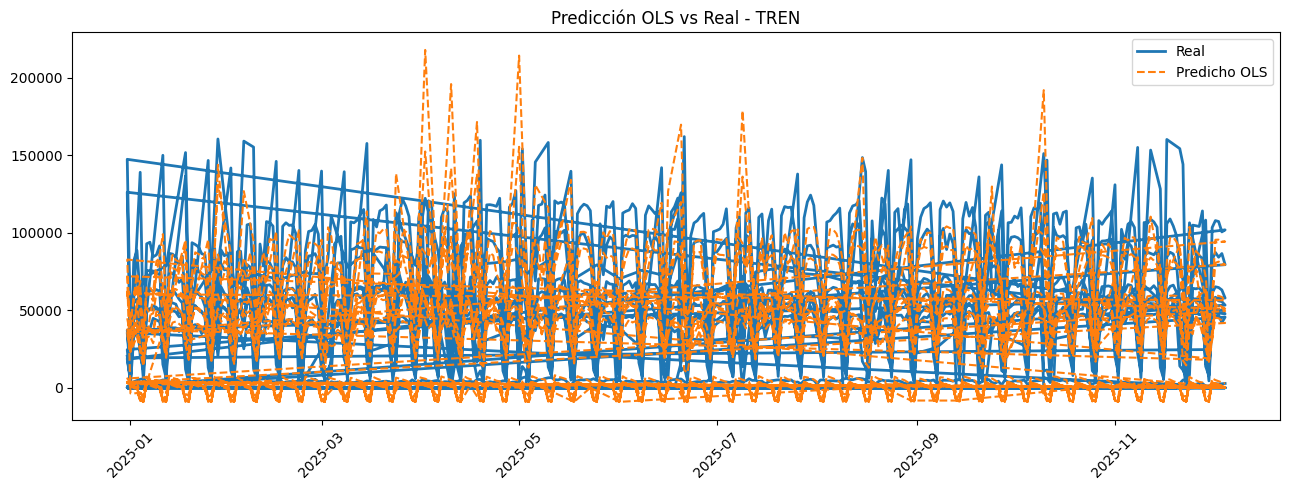

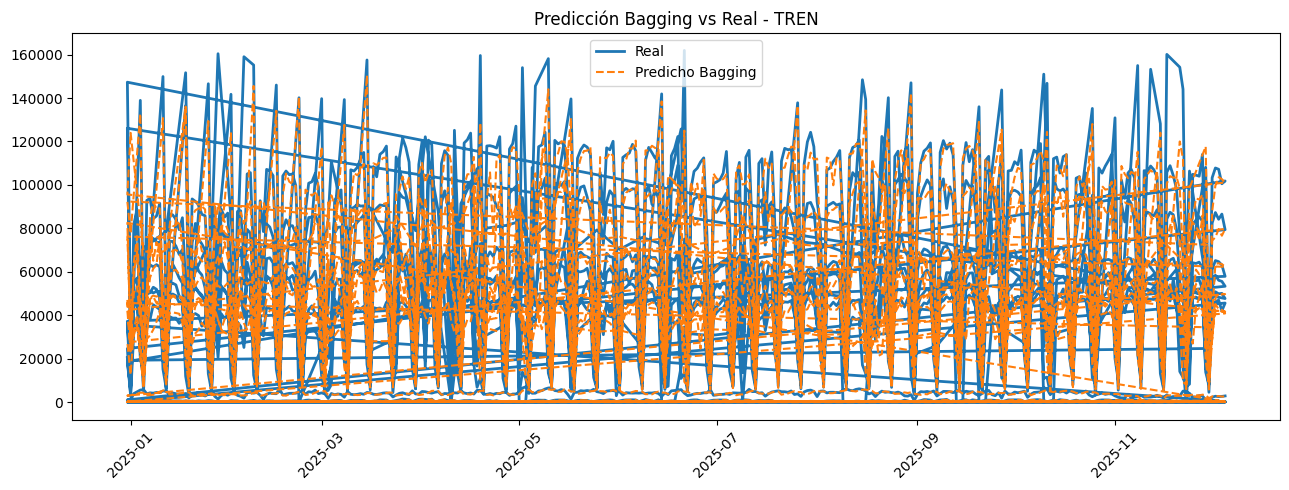

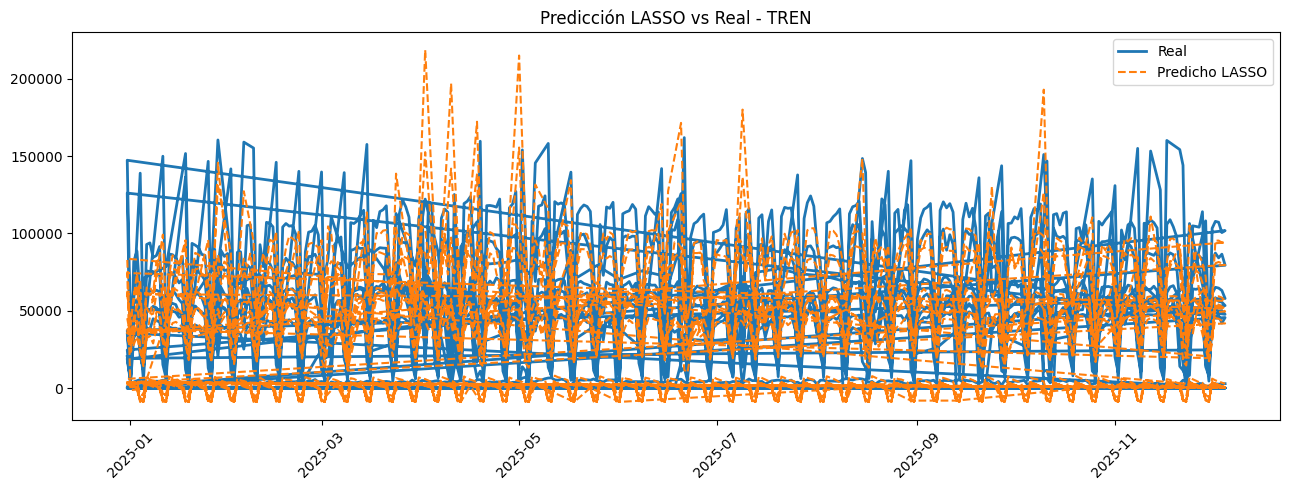

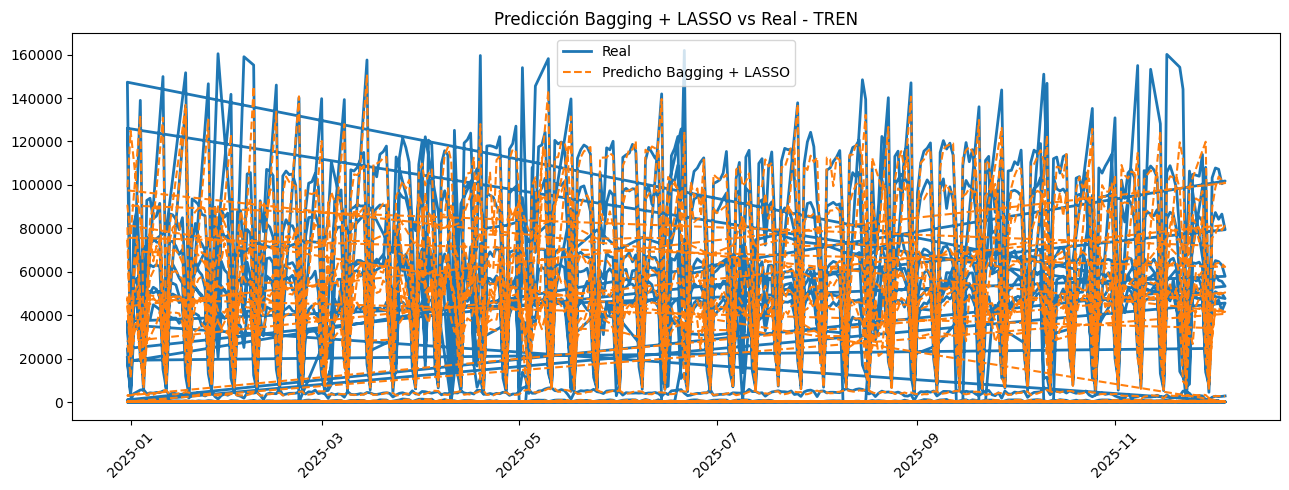

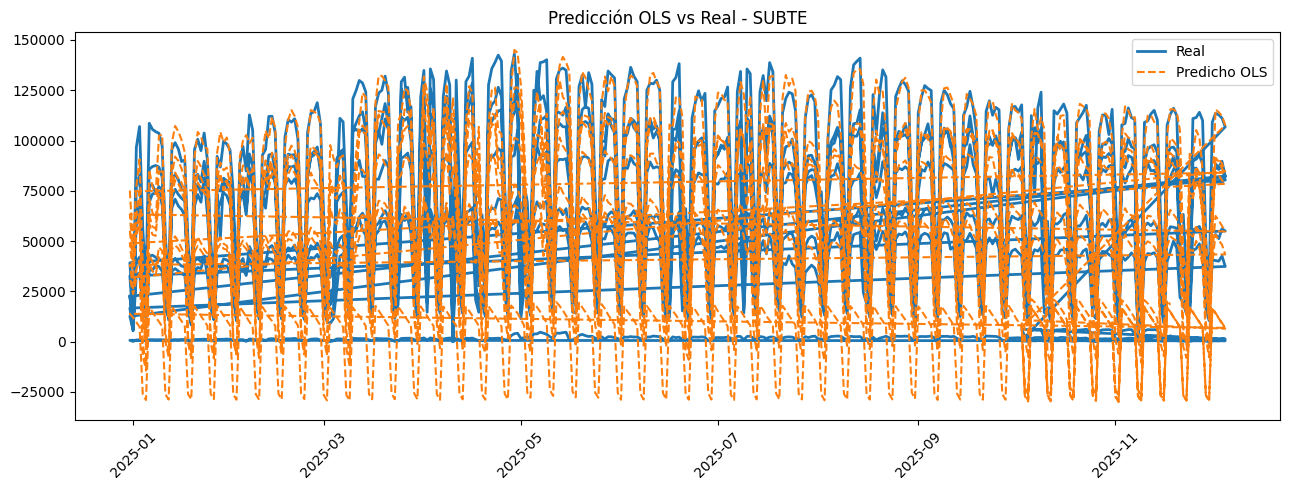

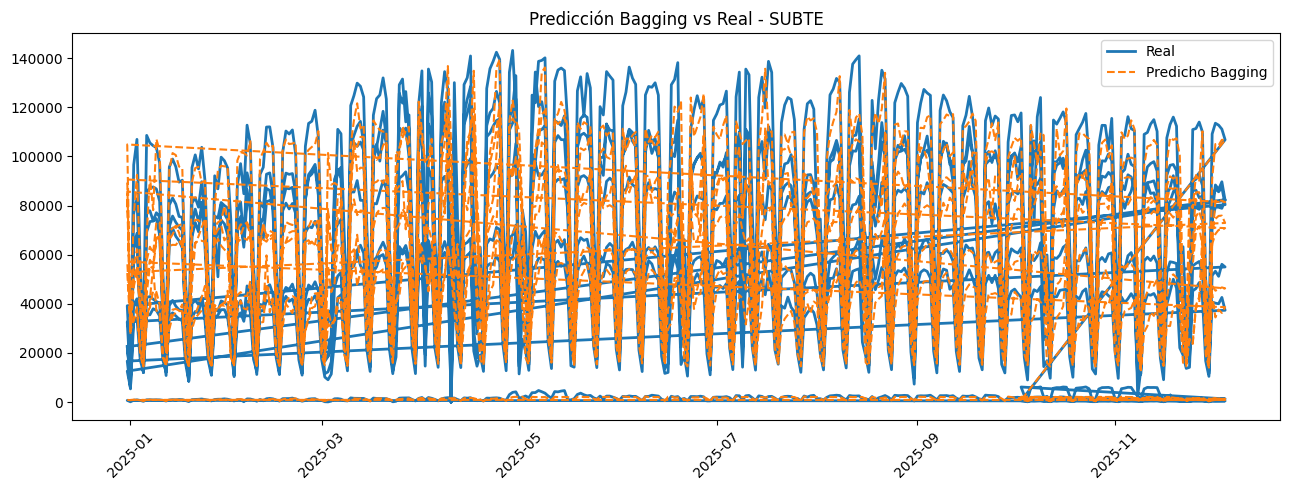

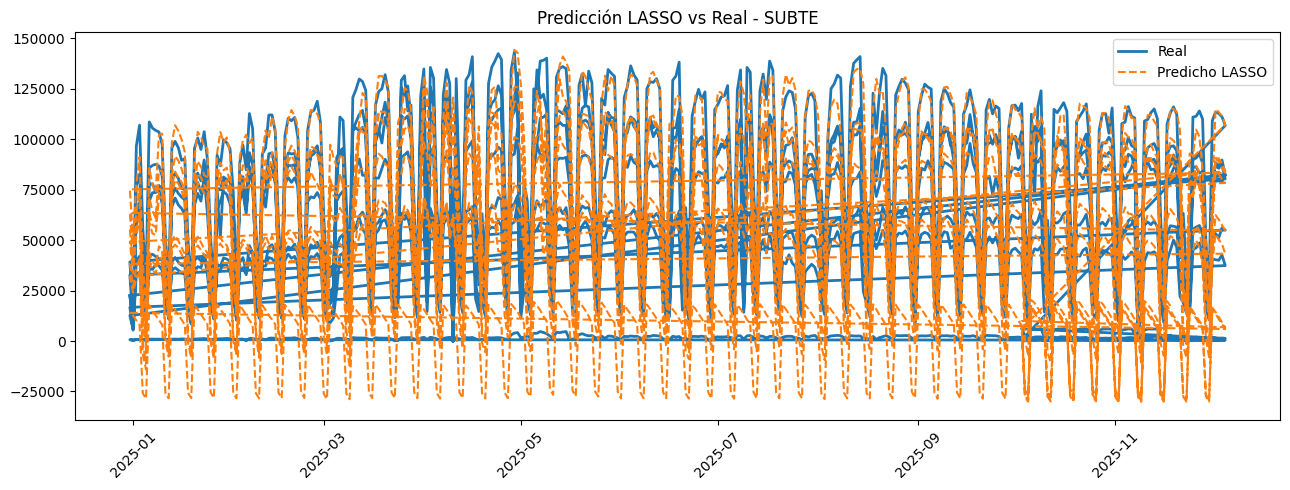

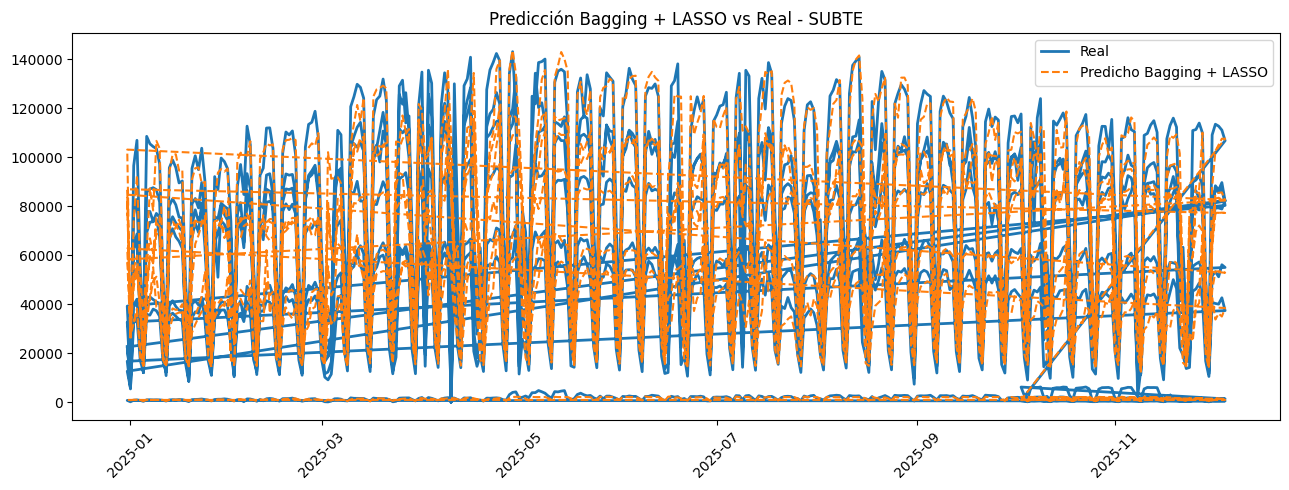

In [68]:
# ==========================================
# GRÁFICOS DE PREDICCIÓN – REAL VS CADA MODELO
# (Un gráfico por modelo y tipo de transporte)
# ==========================================

# ===================
# TREN
# ===================

n_tren = len(y_test_tren)
fechas_tren = test_tren["fecha"].iloc[:n_tren]

# 1. OLS vs Real - TREN
plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren.values, label="Real", linewidth=2)
plt.plot(fechas_tren, y_pred_ols_tren[:n_tren], label="Predicho OLS", linestyle="--")
plt.title("Predicción OLS vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bagging (pipeline) vs Real - TREN
plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren.values, label="Real", linewidth=2)
plt.plot(fechas_tren, y_pred_tren[:n_tren], label="Predicho Bagging", linestyle="--")
plt.title("Predicción Bagging vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. LASSO vs Real - TREN
plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren.values, label="Real", linewidth=2)
plt.plot(fechas_tren, res_tren["y_pred_lasso"][:n_tren], label="Predicho LASSO", linestyle="--")
plt.title("Predicción LASSO vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Bagging + LASSO vs Real - TREN
plt.figure(figsize=(13,5))
plt.plot(fechas_tren, y_test_tren.values, label="Real", linewidth=2)
plt.plot(fechas_tren, res_tren["y_pred_bag_lasso"][:n_tren],
         label="Predicho Bagging + LASSO", linestyle="--")
plt.title("Predicción Bagging + LASSO vs Real - TREN")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# ===================
# SUBTE
# ===================

n_sub = len(y_test_subte)
fechas_sub = test_subte["fecha"].iloc[:n_sub]

# 1. OLS vs Real - SUBTE
plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_subte.values, label="Real", linewidth=2)
plt.plot(fechas_sub, y_pred_ols_subte[:n_sub], label="Predicho OLS", linestyle="--")
plt.title("Predicción OLS vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bagging (pipeline) vs Real - SUBTE
plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_subte.values, label="Real", linewidth=2)
plt.plot(fechas_sub, y_pred_subte[:n_sub], label="Predicho Bagging", linestyle="--")
plt.title("Predicción Bagging vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. LASSO vs Real - SUBTE
plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_subte.values, label="Real", linewidth=2)
plt.plot(fechas_sub, res_subte["y_pred_lasso"][:n_sub], label="Predicho LASSO", linestyle="--")
plt.title("Predicción LASSO vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Bagging + LASSO vs Real - SUBTE
plt.figure(figsize=(13,5))
plt.plot(fechas_sub, y_test_subte.values, label="Real", linewidth=2)
plt.plot(fechas_sub, res_subte["y_pred_bag_lasso"][:n_sub],
         label="Predicho Bagging + LASSO", linestyle="--")
plt.title("Predicción Bagging + LASSO vs Real - SUBTE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### OTROS GRÁFICOS

## EXTENSION (filtrado por outliers)

Retomamos los boxplot para visualizar los outlier tren y subte, por linea.

/tmp/ipython-input-3881870128.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tren_filtrado["ANIO"]  = pd.to_datetime(df_tren_filtrado["DIA_TRANSPORTE"]).dt.year
/tmp/ipython-input-3881870128.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_subte_filtrado["ANIO"] = pd.to_datetime(df_subte_filtrado["DIA_TRANSPORTE"]).dt.year
/tmp/ipython-input-3881870128.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the o

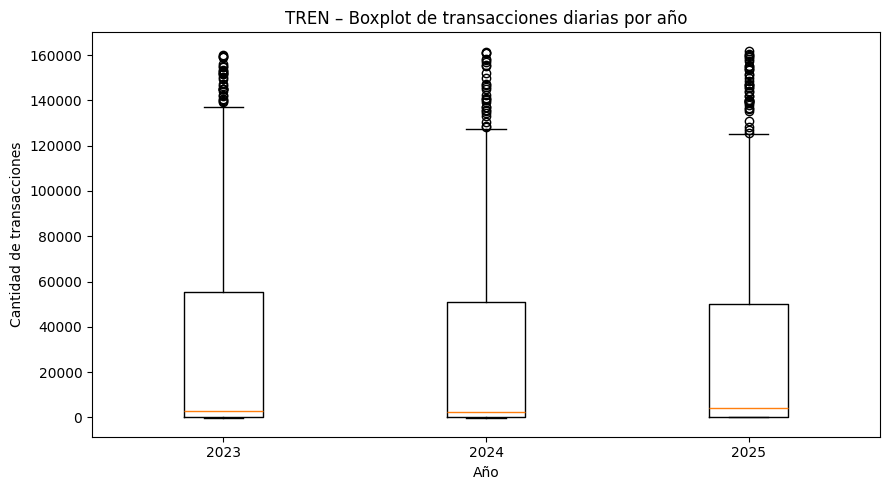

/tmp/ipython-input-3881870128.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_subte, labels=labels_subte, showfliers=True)


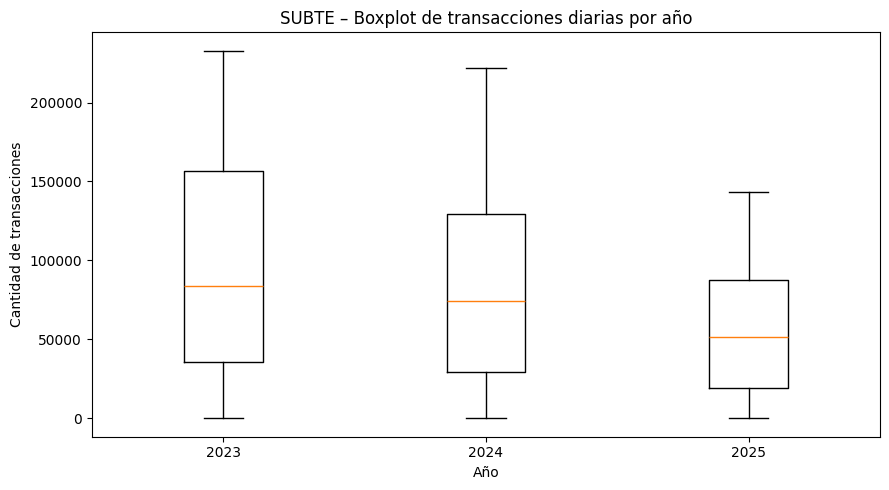

In [82]:
# Asegurar año en ambos datasets
df_tren_filtrado["ANIO"]  = pd.to_datetime(df_tren_filtrado["DIA_TRANSPORTE"]).dt.year
df_subte_filtrado["ANIO"] = pd.to_datetime(df_subte_filtrado["DIA_TRANSPORTE"]).dt.year

# Datos por año
data_tren = [
    df_tren_filtrado[df_tren_filtrado["ANIO"] == anio]["CANTIDAD"].dropna()
    for anio in sorted(df_tren_filtrado["ANIO"].unique())
]

labels_tren = sorted(df_tren_filtrado["ANIO"].unique())

plt.figure(figsize=(9,5))
plt.boxplot(data_tren, labels=labels_tren, showfliers=True)
plt.title("TREN – Boxplot de transacciones diarias por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de transacciones")
plt.tight_layout()
plt.show()

# Datos por año
data_subte = [
    df_subte_filtrado[df_subte_filtrado["ANIO"] == anio]["CANTIDAD"].dropna()
    for anio in sorted(df_subte_filtrado["ANIO"].unique())
]

labels_subte = sorted(df_subte_filtrado["ANIO"].unique())

plt.figure(figsize=(9,5))
plt.boxplot(data_subte, labels=labels_subte, showfliers=True)
plt.title("SUBTE – Boxplot de transacciones diarias por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de transacciones")
plt.tight_layout()
plt.show()



Vemos que hay outliers para tren pero no para subte. Veamos que lineas explican, en terminos generales, los outliers del dataset de tren.

In [75]:
# =====================================================
# OUTLIERS DEL TREN (DATASET COMPLETO)
# EXPLICADOS POR LINEA
# =====================================================

# 1) IQR GLOBAL sobre df_tren_filtrado
q1 = df_tren_filtrado["CANTIDAD"].quantile(0.25)
q3 = df_tren_filtrado["CANTIDAD"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

print("IQR GLOBAL TREN (df_tren_filtrado)")
print(f"Q1    : {q1:.2f}")
print(f"Q3    : {q3:.2f}")
print(f"Lower : {lower:.2f}")
print(f"Upper : {upper:.2f}")

# 2) Marcar outliers globales
df_tren_global = df_tren_filtrado.copy()
df_tren_global["es_outlier_global"] = (
    (df_tren_global["CANTIDAD"] < lower) |
    (df_tren_global["CANTIDAD"] > upper)
)

print("\nTotal de outliers globales detectados:",
      df_tren_global["es_outlier_global"].sum())

# 3) Tabla: explicación por línea
tabla_outliers_global_tren = (
    df_tren_global
      .groupby("LINEA")
      .agg(
          TOTAL_OBS=("CANTIDAD", "size"),
          N_OUTLIERS=("es_outlier_global", "sum")
      )
)

tabla_outliers_global_tren["PORC_OUTLIERS"] = (
    tabla_outliers_global_tren["N_OUTLIERS"] /
    tabla_outliers_global_tren["TOTAL_OBS"]
)

tabla_outliers_global_tren = (
    tabla_outliers_global_tren
      .sort_values("PORC_OUTLIERS", ascending=False)
)

print("\n=== OUTLIERS GLOBALES DEL TREN (DATASET COMPLETO) ===")
print(tabla_outliers_global_tren)

IQR GLOBAL TREN (df_tren_filtrado)
Q1    : 133.00
Q3    : 52776.00
Lower : -78831.50
Upper : 131740.50

Total de outliers globales detectados: 96

=== OUTLIERS GLOBALES DEL TREN (DATASET COMPLETO) ===
                            TOTAL_OBS  N_OUTLIERS  PORC_OUTLIERS
LINEA                                                           
FFCC SAR                          317          81       0.255521
FFCC ROCA                         205          15       0.073171
FCC MITRE_TIGRE                  1036           0       0.000000
FFCC SAR  MERLO - LOBOS           607           0       0.000000
FFCC SAR MORENO - MERCEDES        609           0       0.000000
FFCC URQUIZA                     1063           0       0.000000
FFCC_BELGRANO_NORTE              1063           0       0.000000
FFCC_BELG_SUR                    1063           0       0.000000
FFCC_MITRE                       1037           0       0.000000
FFCC_MITRE_CAPILLA                689           0       0.000000
FFCC_MITRE_ZARATE  

Sacamos el Roca y el Sarmiento, que explican la totalidad de los outliers, para aplicar a los modelos antes especificados, con el fin de ver si mejoran las predicciones de los modelos.

In [76]:
# ==============================
# 1. TREN filtrado sin SAR y ROCA
# ==============================

lineas_excluir = ["FFCC SAR", "FFCC ROCA"]

df_tren_sin_sar_roca = df_tren_filtrado[
    ~df_tren_filtrado["LINEA"].isin(lineas_excluir)
].copy()

# Asegurar fecha
df_tren_sin_sar_roca["DIA_TRANSPORTE"] = pd.to_datetime(
    df_tren_sin_sar_roca["DIA_TRANSPORTE"]
)

print("Obs TREN filtrado total     :", len(df_tren_filtrado))
print("Obs TREN sin SAR y ROCA     :", len(df_tren_sin_sar_roca))
print("Líneas incluidas:", df_tren_sin_sar_roca["LINEA"].unique())


Obs TREN filtrado total     : 15601
Obs TREN sin SAR y ROCA     : 15079
Líneas incluidas: ['FCC MITRE_TIGRE' 'FFCC SAR  MERLO - LOBOS' 'FFCC SAR MORENO - MERCEDES'
 'FFCC URQUIZA' 'FFCC_BELGRANO_NORTE' 'FFCC_BELG_SUR' 'FFCC_MITRE'
 'FFCC_MITRE_CAPILLA' 'FFCC_MITRE_ZARATE' 'FFCC_ROCA_CAÑUELAS-LOBOS'
 'FFCC_ROCA_CAÑUELAS-MONTE' 'FFCC_ROCA_KORN-CHASCOMUS'
 'FFCC_ROCA_UNIVERSITARIO' 'FFCC_SANM' 'FFCC_SUAREZ' 'FFCC_TREN_COSTA']


In [77]:
# ==============================
# Train / Test split temporal
# ==============================

train_tren_sr, test_tren_sr = hacer_split_train_test(
    df_tren_sin_sar_roca, "TREN sin SAR y ROCA", corte
)

# ==============================
# Preparar X e y
# ==============================

X_train_tren_sr, y_train_tren_sr, X_test_tren_sr, y_test_tren_sr = preparar_X_y(
    train_tren_sr, test_tren_sr, "TREN sin SAR y ROCA"
)



=== Split para TREN sin SAR y ROCA ===
Split inicial por fecha:
Train: (10684, 21)
Test : (4395, 21)

Variables listas para TREN sin SAR y ROCA:
X_train: (10684, 10) | y_train: (10684,)
X_test : (4395, 10) | y_test : (4395,)


### ENTRENAMIENTO Y MÉTRICAS

In [78]:
# ============================================
#  Entrenar modelo LASSO + Bagging
# ============================================

result_tren_sin_sar_roca = entrenar_modelo_con_lasso_y_bagging(
    X_train_tren_sr,
    y_train_tren_sr,
    X_test_tren_sr,
    y_test_tren_sr,
    nombre_modelo="TREN sin SAR y ROCA"
)


 ENTRENANDO MODELO: TREN sin SAR y ROCA

🔎 Mejor alpha para LASSO (TREN sin SAR y ROCA): 5.455595

📊 MÉTRICAS DEL MODELO LASSO (TREN sin SAR y ROCA)
   ▶ MAE  : 6008.8102
   ▶ RMSE : 10273.6643
   ▶ R²   : 0.9057

✅ Variables seleccionadas por LASSO para TREN sin SAR y ROCA:
['lag_1' 'lag_7' 'media_7' 'media_30' 'mes' 'dia_mes' 'dia_semana'
 'fin_semana' 'LINEA_FFCC_ROCA_UNIVERSITARIO' 'LINEA_FFCC_SANM']

📊 MÉTRICAS BAGGING CON LASSO PREVIO PARA TREN sin SAR y ROCA
   ▶ MAE  : 3563.7150
   ▶ RMSE : 8319.6885
   ▶ R²   : 0.9381



In [79]:
# ==============================
# BAGGING REGRESSOR – TREN sin SAR y ROCA
# ==============================

print("\n==============================")
print(" BAGGING: TREN sin SAR y ROCA")
print("==============================")

# Árbol base
base_tree_sr = DecisionTreeRegressor(
    max_depth=None,
    random_state=42
)

# Bagging para TREN sin SAR y ROCA
bagging_tren_sr = BaggingRegressor(
    estimator=base_tree_sr,
    n_estimators=200,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

# Preprocesamiento: numéricas + OneHot de LINEA
preprocess_tren_sr = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Pipeline completo
pipe_tren_sr = Pipeline(steps=[
    ("prep", preprocess_tren_sr),
    ("model", bagging_tren_sr)
])

# Entrenar
pipe_tren_sr.fit(X_train_tren_sr, y_train_tren_sr)

# Predicciones en TEST
y_pred_tren_sr = pipe_tren_sr.predict(X_test_tren_sr)

# Métricas
mse_tren_sr  = mean_squared_error(y_test_tren_sr, y_pred_tren_sr)
rmse_tren_sr = np.sqrt(mse_tren_sr)
mae_tren_sr  = mean_absolute_error(y_test_tren_sr, y_pred_tren_sr)
r2_tren_sr   = r2_score(y_test_tren_sr, y_pred_tren_sr)

print("\n📊 MÉTRICAS BAGGING – TREN sin SAR y ROCA")
print(f"   ▶ MAE  : {mae_tren_sr:.4f}")
print(f"   ▶ RMSE : {rmse_tren_sr:.4f}")
print(f"   ▶ R²   : {r2_tren_sr:.44f}")


 BAGGING: TREN sin SAR y ROCA

📊 MÉTRICAS BAGGING – TREN sin SAR y ROCA
   ▶ MAE  : 3519.0077
   ▶ RMSE : 8271.3962
   ▶ R²   : 0.93886508362943787986409915902186185121536255


In [80]:
# ==========================================
# COMPARACIÓN OLS – TREN sin SAR y ROCA
# ==========================================

mae_ols_tren_sr = rmse_ols_tren_sr = r2_ols_tren_sr = None
y_pred_ols_tren_sr = None

print("\n================ OLS TREN sin SAR y ROCA ================")

# OneHot para OLS
X_train_dum = pd.get_dummies(
    X_train_tren_sr,
    columns=categorical_features,
    drop_first=True
)

X_test_dum = pd.get_dummies(
    X_test_tren_sr,
    columns=categorical_features,
    drop_first=True
)

# y como float
y_train_ols = y_train_tren_sr.astype(float)
y_test_ols  = y_test_tren_sr.astype(float)

# Limpiar NaN SOLO en train
df_train = pd.concat(
    [y_train_ols.rename("CANTIDAD"), X_train_dum],
    axis=1
).dropna()

y_train_ols = df_train["CANTIDAD"]
X_train_ols = df_train.drop(columns="CANTIDAD")

# Alinear test con train
X_test_ols = X_test_dum.reindex(
    columns=X_train_ols.columns,
    fill_value=0
)

# A float
X_train_ols = X_train_ols.astype(float)
X_test_ols  = X_test_ols.astype(float)

# Constante
X_train_ols = sm.add_constant(X_train_ols)
X_test_ols  = sm.add_constant(X_test_ols)

# Ajustar modelo OLS
ols_model_tren_sr = sm.OLS(y_train_ols, X_train_ols).fit()
print(ols_model_tren_sr.summary())

# Predicción
y_pred_ols = ols_model_tren_sr.predict(X_test_ols)

# Assign to y_pred_ols_tren_sr for later plotting
y_pred_ols_tren_sr = y_pred_ols

# Quitar NaN en test para métricas
mask = (~y_test_ols.isna()) & (~pd.isna(y_pred_ols))
y_test_valid = y_test_ols[mask]
y_pred_valid = y_pred_ols[mask]

# Métricas OLS
mae_ols_tren_sr  = mean_absolute_error(y_test_valid, y_pred_valid)
rmse_ols_tren_sr = np.sqrt(mean_squared_error(y_test_valid, y_pred_valid))
r2_ols_tren_sr   = r2_score(y_test_valid, y_pred_valid)

print("\nMÉTRICAS OLS (TREN sin SAR y ROCA)")
print(f"MAE : {mae_ols_tren_sr:,.2f}")
print(f"RMSE: {rmse_ols_tren_sr:,.2f}")
print(f"R²  : {r2_ols_tren_sr:,.3f}")



================ OLS TREN sin SAR y ROCA ================
                            OLS Regression Results                            
Dep. Variable:               CANTIDAD   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     4533.
Date:                mié, 10 dic 2025   Prob (F-statistic):               0.00
Time:                        16:03:08   Log-Likelihood:            -1.1381e+05
No. Observations:               10684   AIC:                         2.277e+05
Df Residuals:                   10659   BIC:                         2.278e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------

In [81]:
# ============================
# TABLA COMPARATIVA – TODOS LOS MODELOS
# ============================

filas = []

# ======================
# TREN – DATASET COMPLETO
# ======================
filas.append({
    "Tipo": "TREN",
    "Escenario": "Completo",
    "Modelo": "OLS",
    "MAE": mae_ols_tren,
    "RMSE": rmse_ols_tren,
    "R2": r2_ols_tren
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Completo",
    "Modelo": "Bagging (pipeline)",
    "MAE": mae_tren,
    "RMSE": rmse_tren,
    "R2": r2_tren
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Completo",
    "Modelo": "LASSO",
    "MAE": res_tren["mae_lasso"],
    "RMSE": res_tren["rmse_lasso"],
    "R2": res_tren["r2_lasso"]
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Completo",
    "Modelo": "Bagging + LASSO",
    "MAE": res_tren["mae_bag_lasso"],
    "RMSE": res_tren["rmse_bag_lasso"],
    "R2": res_tren["r2_bag_lasso"]
})

# ==========================
# TREN – SIN SAR Y ROCA
# ==========================
filas.append({
    "Tipo": "TREN",
    "Escenario": "Sin SAR y ROCA",
    "Modelo": "OLS",
    "MAE": mae_ols_tren_sr,
    "RMSE": rmse_ols_tren_sr,
    "R2": r2_ols_tren_sr
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Sin SAR y ROCA",
    "Modelo": "Bagging (pipeline)",
    "MAE": mae_tren_sr,
    "RMSE": rmse_tren_sr,
    "R2": r2_tren_sr
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Sin SAR y ROCA",
    "Modelo": "LASSO",
    "MAE": result_tren_sin_sar_roca["mae_lasso"],
    "RMSE": result_tren_sin_sar_roca["rmse_lasso"],
    "R2": result_tren_sin_sar_roca["r2_lasso"]
})

filas.append({
    "Tipo": "TREN",
    "Escenario": "Sin SAR y ROCA",
    "Modelo": "Bagging + LASSO",
    "MAE": result_tren_sin_sar_roca["mae_bag_lasso"],
    "RMSE": result_tren_sin_sar_roca["rmse_bag_lasso"],
    "R2": result_tren_sin_sar_roca["r2_bag_lasso"]
})

# ======================
# ARMAR DATAFRAME FINAL
# ======================
tabla_resultados = pd.DataFrame(filas)
tabla_resultados


,Tipo,Escenario,Modelo,MAE,RMSE,R2
0,TREN,Completo,OLS,8313.615164,14018.839456,0.843235
1,TREN,Completo,Bagging (pipeline),3990.228247,9556.837340,0.927146
2,TREN,Completo,LASSO,8325.631787,14014.131910,0.843340
3,TREN,Completo,Bagging + LASSO,3991.217318,9527.680656,0.927590
4,TREN,Sin SAR y ROCA,OLS,6056.089682,10278.399944,0.905598
5,TREN,Sin SAR y ROCA,Bagging (pipeline),3519.007652,8271.396200,0.938865
6,TREN,Sin SAR y ROCA,LASSO,6008.810226,10273.664314,0.905685
7,TREN,Sin SAR y ROCA,Bagging + LASSO,3563.714982,8319.688526,0.938149


### Gráficos

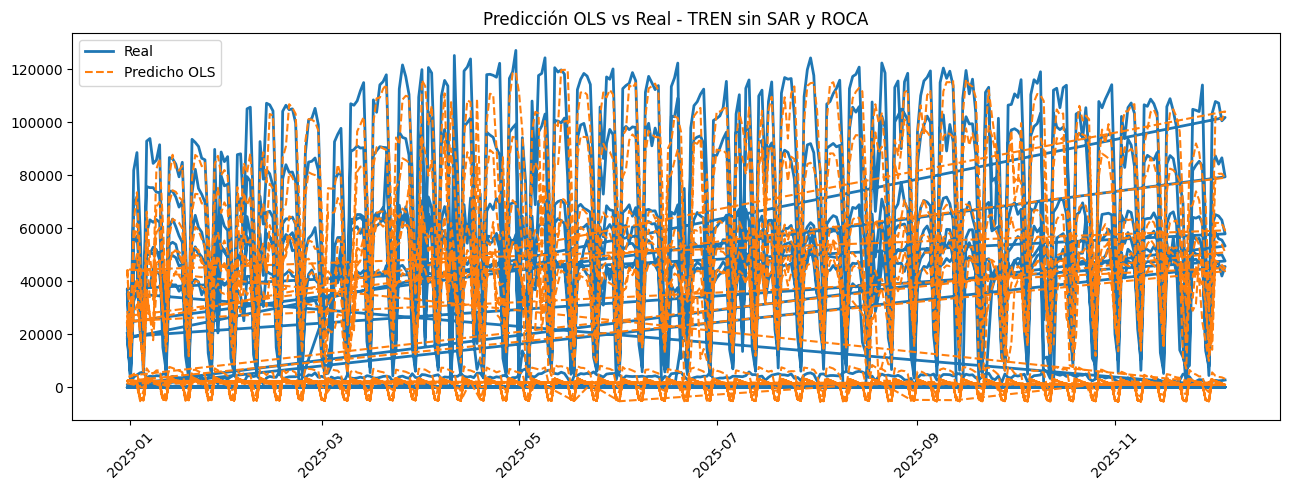

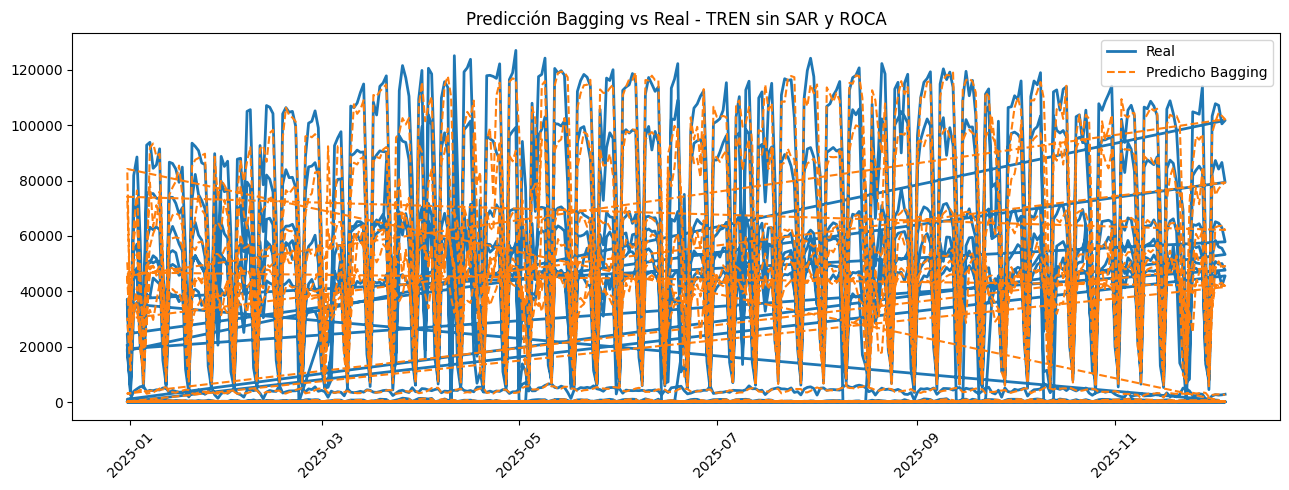

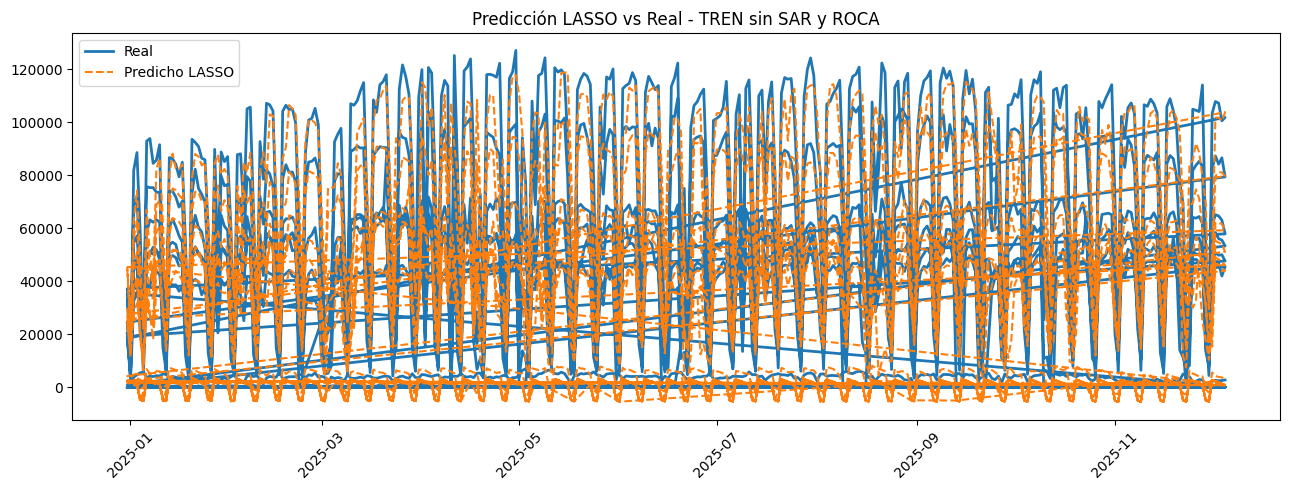

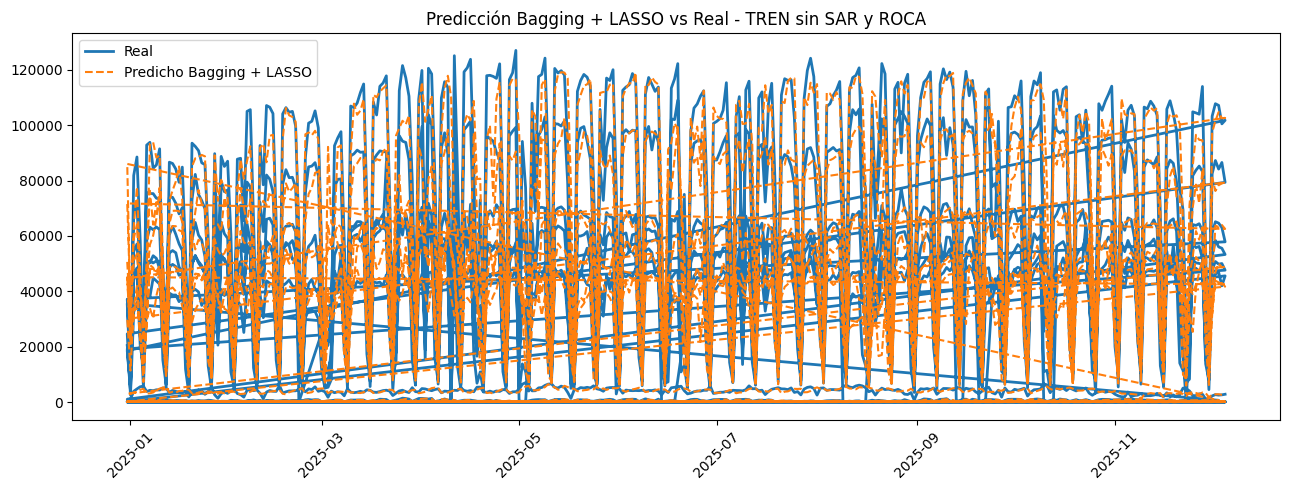

In [97]:
# ==========================================
# GRÁFICOS DE PREDICCIÓN – REAL VS CADA MODELO
# TREN sin SAR y ROCA
# ==========================================

# ===================
# TREN sin SAR y ROCA
# ===================

n_tren_sr = len(y_test_tren_sr)
fechas_tren_sr = test_tren_sr["fecha"].iloc[:n_tren_sr]

# 1. OLS vs Real - TREN sin SAR y ROCA
plt.figure(figsize=(13,5))
plt.plot(fechas_tren_sr, y_test_tren_sr.values, label="Real", linewidth=2)
plt.plot(fechas_tren_sr,
         y_pred_ols_tren_sr[:n_tren_sr],
         label="Predicho OLS",
         linestyle="--")
plt.title("Predicción OLS vs Real - TREN sin SAR y ROCA")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Bagging (pipeline) vs Real - TREN sin SAR y ROCA
plt.figure(figsize=(13,5))
plt.plot(fechas_tren_sr, y_test_tren_sr.values, label="Real", linewidth=2)
plt.plot(fechas_tren_sr,
         y_pred_tren_sr[:n_tren_sr],
         label="Predicho Bagging",
         linestyle="--")
plt.title("Predicción Bagging vs Real - TREN sin SAR y ROCA")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. LASSO vs Real - TREN sin SAR y ROCA
plt.figure(figsize=(13,5))
plt.plot(fechas_tren_sr, y_test_tren_sr.values, label="Real", linewidth=2)
plt.plot(fechas_tren_sr,
         result_tren_sin_sar_roca["y_pred_lasso"][:n_tren_sr],
         label="Predicho LASSO",
         linestyle="--")
plt.title("Predicción LASSO vs Real - TREN sin SAR y ROCA")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Bagging + LASSO vs Real - TREN sin SAR y ROCA
plt.figure(figsize=(13,5))
plt.plot(fechas_tren_sr, y_test_tren_sr.values, label="Real", linewidth=2)
plt.plot(fechas_tren_sr,
         result_tren_sin_sar_roca["y_pred_bag_lasso"][:n_tren_sr],
         label="Predicho Bagging + LASSO",
         linestyle="--")
plt.title("Predicción Bagging + LASSO vs Real - TREN sin SAR y ROCA")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
